# The Relationship Between the Average Rate of Change, the Mean Value Theorem, and the Net Change Theorem

The three ideas — **Average Rate of Change**, the **Mean Value Theorem**, and the **Net Change Theorem** — form a single, unified picture of how derivatives and integrals describe change.

---

## **1. Average Rate of Change (AROC)**

For a function $F(x)$ on an interval $[a,b]$, the average rate of change is:

$
\text{AROC} = \frac{F(b)-F(a)}{b-a}
$

This is the slope of the **secant line** between the points $(a, F(a))$ and $(b, F(b))$.

It measures how fast the function changed *on average* over the interval.

---

## **2. Net Change Theorem (NCT)**

If $F'(x) = f(x)$, then:

$
\int_a^b f(x)\,dx = F(b) - F(a)
$

This says:

- Integrating a **rate** gives the **total accumulated change**.
- The integral of velocity gives displacement.
- The integral of flow rate gives total volume.
- The integral of growth rate gives total growth.

Using this theorem, we can rewrite AROC as:

$
\text{AROC} = \frac{1}{b-a} \int_a^b F'(x)\,dx
$

So the average rate of change of $F$ equals the **average value of its derivative**.

---

## **3. Mean Value Theorem (MVT)**

If $F$ is continuous on $[a,b]$ and differentiable on $(a,b)$, then there exists a point $c\in(a,b)$ such that:

$
F'(c) = \frac{F(b)-F(a)}{b-a}
$

This guarantees that the **instantaneous rate** equals the **average rate** at some moment.

Geometrically:  
The tangent line at $x=c$ has the same slope as the secant line from $a$ to $b$.

---

## **4. The Unifying Identity**

All three ideas connect through the identity:

$
\frac{F(b)-F(a)}{b-a}
= \frac{1}{b-a}\int_a^b F'(x)\,dx
= F'(c)
$

This means:

- **Net Change Theorem** gives the total change $F(b)-F(a)$.  
- **Average Rate of Change** divides that total change by the interval length.  
- **Mean Value Theorem** guarantees a point where the instantaneous rate matches that average.


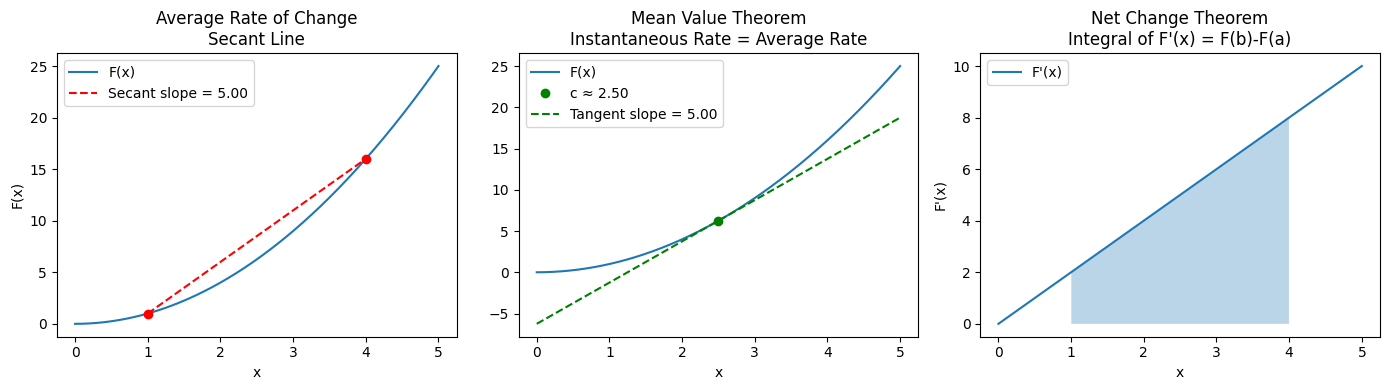

Average Rate of Change: 5.0
Instantaneous Rate at c: 5.0
Net Change F(b)-F(a): 15
Integral of F'(x) from a to b (should match): (15.0, 1.6653345369377348e-13)


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import fsolve
from scipy.integrate import quad

# ---------------------------------------------------------
# Function definition (you can swap this out as needed)
# ---------------------------------------------------------
F = lambda x: x**2
Fp = lambda x: 2*x

a, b = 1, 4

# ---------------------------------------------------------
# Compute values
# ---------------------------------------------------------
x = np.linspace(a-1, b+1, 400)
secant_slope = (F(b) - F(a)) / (b - a)

# Solve F'(c) = secant_slope for the MVT point
c_guess = (a + b) / 2
c = fsolve(lambda t: Fp(t) - secant_slope, c_guess)[0]

# ---------------------------------------------------------
# Plot 1: Secant line (Average Rate of Change)
# ---------------------------------------------------------
plt.figure(figsize=(14,4))
plt.subplot(1,3,1)
plt.plot(x, F(x), label="F(x)")
plt.plot([a,b], [F(a),F(b)], 'ro')
plt.plot([a,b], [F(a),F(b)], 'r--', label=f"Secant slope = {secant_slope:.2f}")
plt.title("Average Rate of Change\nSecant Line")
plt.xlabel("x")
plt.ylabel("F(x)")
plt.legend()

# ---------------------------------------------------------
# Plot 2: Tangent line at c (Mean Value Theorem)
# ---------------------------------------------------------
plt.subplot(1,3,2)
plt.plot(x, F(x), label="F(x)")
plt.plot(c, F(c), 'go', label=f"c ≈ {c:.2f}")
tangent_line = F(c) + Fp(c)*(x - c)
plt.plot(x, tangent_line, 'g--', label=f"Tangent slope = {Fp(c):.2f}")
plt.title("Mean Value Theorem\nInstantaneous Rate = Average Rate")
plt.xlabel("x")
plt.legend()

# ---------------------------------------------------------
# Plot 3: Net Change Theorem (Integral Visualization)
# ---------------------------------------------------------
plt.subplot(1,3,3)
plt.plot(x, Fp(x), label="F'(x)")
plt.fill_between(x[(x>=a)&(x<=b)], Fp(x[(x>=a)&(x<=b)]), alpha=0.3)
plt.title("Net Change Theorem\nIntegral of F'(x) = F(b)-F(a)")
plt.xlabel("x")
plt.ylabel("F'(x)")
plt.legend()

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# Print the key relationships numerically
# ---------------------------------------------------------
print("Average Rate of Change:", secant_slope)
print("Instantaneous Rate at c:", Fp(c))
print("Net Change F(b)-F(a):", F(b)-F(a))
print("Integral of F'(x) from a to b (should match):", quad(Fp, a, b))

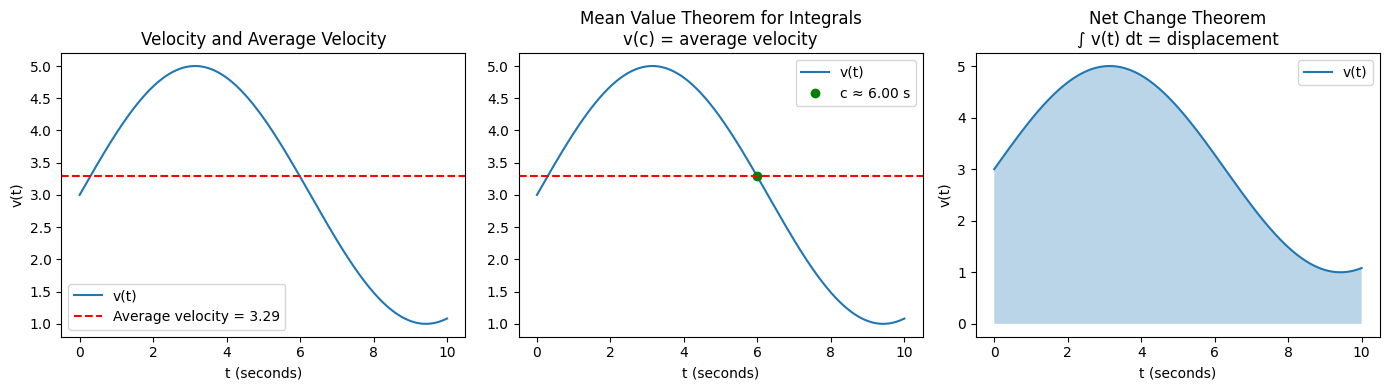

Average velocity: 3.2865351258147095
Instantaneous velocity at c: 3.2865351258147384
Displacement s(b)-s(a): 32.86535125814709
Integral of v(t) (numerical): (32.86535125814709, 3.648786967918826e-13)


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import fsolve
from scipy.integrate import quad

# ---------------------------------------------------------
# Motion model (customizable)
# ---------------------------------------------------------
# Velocity function v(t)
v = lambda t: 3 + 2*np.sin(t/2)     # smooth, realistic acceleration/deceleration
# Position function s(t) via antiderivative (for plotting only)
# (We approximate s(t) numerically)
def position(t_array):
    return np.array([quad(v, t_array[0], t_array[i])[0] for i in range(len(t_array))])

a, b = 0, 10   # time interval in seconds

# ---------------------------------------------------------
# Compute values
# ---------------------------------------------------------
t = np.linspace(a, b, 400)
s = position(t)

# Average velocity
avg_v = (s[-1] - s[0]) / (b - a)

# Solve v(c) = average velocity (MVT for integrals)
c_guess = (a + b) / 2
c = fsolve(lambda x: v(x) - avg_v, c_guess)[0]

# ---------------------------------------------------------
# Plot 1: Velocity curve + average velocity line
# ---------------------------------------------------------
plt.figure(figsize=(14,4))
plt.subplot(1,3,1)
plt.plot(t, v(t), label="v(t)")
plt.axhline(avg_v, color='r', linestyle='--', label=f"Average velocity = {avg_v:.2f}")
plt.title("Velocity and Average Velocity")
plt.xlabel("t (seconds)")
plt.ylabel("v(t)")
plt.legend()

# ---------------------------------------------------------
# Plot 2: MVT point where v(c) = average velocity
# ---------------------------------------------------------
plt.subplot(1,3,2)
plt.plot(t, v(t), label="v(t)")
plt.plot(c, v(c), 'go', label=f"c ≈ {c:.2f} s")
plt.axhline(avg_v, color='r', linestyle='--')
plt.title("Mean Value Theorem for Integrals\nv(c) = average velocity")
plt.xlabel("t (seconds)")
plt.legend()

# ---------------------------------------------------------
# Plot 3: Net Change Theorem (area under velocity)
# ---------------------------------------------------------
plt.subplot(1,3,3)
plt.plot(t, v(t), label="v(t)")
plt.fill_between(t, v(t), alpha=0.3)
plt.title("Net Change Theorem\n∫ v(t) dt = displacement")
plt.xlabel("t (seconds)")
plt.ylabel("v(t)")
plt.legend()

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# Print key relationships
# ---------------------------------------------------------
print("Average velocity:", avg_v)
print("Instantaneous velocity at c:", v(c))
print("Displacement s(b)-s(a):", s[-1] - s[0])
print("Integral of v(t) (numerical):", quad(v, a, b))